# 10. Generalized Linear Models in Numerics

This notebook demonstrates Generalized Linear Models (GLMs) - a flexible framework for regression beyond ordinary least squares.

## What You'll Learn

- Linear regression (identity link)
- Logistic regression (logit link) for binary outcomes
- Poisson regression (log link) for count data
- Alternative link functions (probit, complementary log-log)
- Model interpretation and diagnostics
- Performance comparisons with R and Bambi

## Applications

Binary classification, count modeling, rate estimation, dose-response analysis.

## Set Up

In [ ]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix
import builtins
list = builtins.list

from System import Array, Double, String
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.MachineLearning import GeneralizedLinearModel
from Numerics.Mathematics.LinearAlgebra import Vector, Matrix
from helper_functions import convert_to_dotnet_array, convert_to_dotnet_2d_array

print("✓ Setup complete")

✓ Setup complete


**Note:** The hardest part of this notebook is switching between Python and .NET formats. When using these functions on your own be patient and take your time to keep everything organized.

## 1. Linear Regression (Identity Link)

The classic: **y = β₀ + β₁x₁ + ε**

Fitted model: Income = 156.60 ± 4.77 + (0.48 ± 0.02) * Consumption
Standard Error: 18.14, Degrees of Freedom: 98

Model Summary:

Generalized Linear Model (100 obs, 2 parameters):
Model for predicting Income:
Parameters:
                   Estimate  Std. Error     z value    Pr(>|z|)
Intercept         156.60402     4.77296      32.811     < 1E-15 ***
β1                  0.47700     0.01532      31.126     < 1E-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 18.1444 on 98 degrees of freedom
AIC: 865.4598  AICc: 865.5835  BIC: 870.6701

Residuals:
       Min        1Q    Median        3Q       Max
  -38.5472  -14.3737    0.9528    9.3524   45.8596



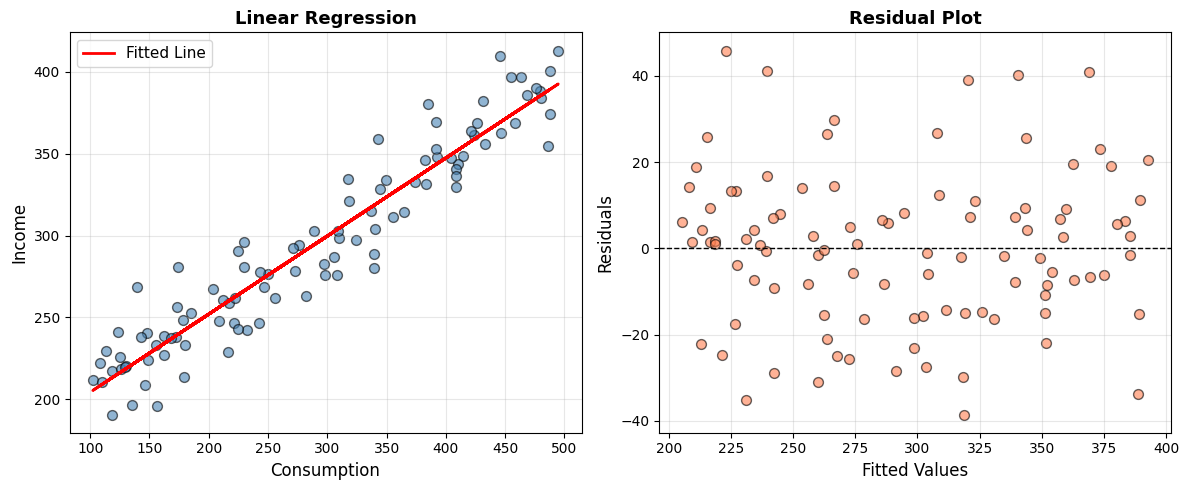

In [ ]:
# Generate simple linear data
np.random.seed(42)
n = 100

consumption = np.random.uniform(100, 500, n)
noise = np.random.normal(0, 20, n)
income = 0.5 * consumption + 150 + noise

X_net_linear = convert_to_dotnet_2d_array(consumption.reshape(-1, 1))
y_net_linear = convert_to_dotnet_array(income)

X_linear = Matrix(X_net_linear)
X_linear.Header = 'Consumption'
y_linear = Vector(y_net_linear)
y_linear.Header = 'Income'

# Fit GLM
glm_linear = GeneralizedLinearModel(X_linear, y_linear)
glm_linear.Train()

a = glm_linear.Parameters[0]  # Intercept
b = glm_linear.Parameters[1]  # Slope
sigA = glm_linear.ParameterStandardErrors[0]
sigB = glm_linear.ParameterStandardErrors[1]
se = glm_linear.StandardError
df = glm_linear.DegreesOfFreedom

summary_lines_linear = glm_linear.Summary()

print(f"Fitted model: Income = {a:.2f} ± {sigA:.2f} + ({b:.2f} ± {sigB:.2f}) * Consumption")
print(f"Standard Error: {se:.2f}, Degrees of Freedom: {df}")
print("\nModel Summary:")
print("\n".join(summary_lines_linear))

# Create design matrix WITH intercept column
# GLM expects: [intercept_column, predictor_columns]
X_array_linear = np.column_stack([
    np.ones(n),     # Intercept column (all 1s)
    consumption     # Predictor
])

X_net_array_linear = convert_to_dotnet_2d_array(X_array_linear)
X_pred_linear = Matrix(X_net_array_linear)

y_pred_linear = glm_linear.Predict(X_pred_linear)

#  Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(consumption, income, alpha=0.6, s=50, color='steelblue', edgecolor='black')
plt.plot(consumption, y_pred_linear, 'r-', linewidth=2, label='Fitted Line')
plt.xlabel('Consumption', fontsize=12)
plt.ylabel('Income', fontsize=12)
plt.title('Linear Regression', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Residuals
residuals = income - y_pred_linear
plt.subplot(1, 2, 2)
plt.scatter(y_pred_linear, residuals, alpha=0.6, s=50, color='coral', edgecolor='black')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Multiple Linear Regression

Multiple predictors: **y = β₀ + β₁x₁ + β₂x₂ + β₃x₃ + ... + ε**


Model Summary:

Generalized Linear Model (150 obs, 4 parameters):
Model for predicting Petal Width:
Parameters:
                   Estimate  Std. Error     z value    Pr(>|z|)
Intercept           0.01300     0.17960       0.072      0.9423  
β1                 -0.24767     0.04783      -5.178   2.25E-007 ***
β2                  0.20302     0.04927       4.120   3.79E-005 ***
β3                  0.53614     0.02466      21.741     < 1E-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1933 on 146 degrees of freedom
AIC: -63.3900  AICc: -63.1142  BIC: -51.3475

Residuals:
       Min        1Q    Median        3Q       Max
   -0.6324   -0.1211   -0.0208    0.0996    0.6322



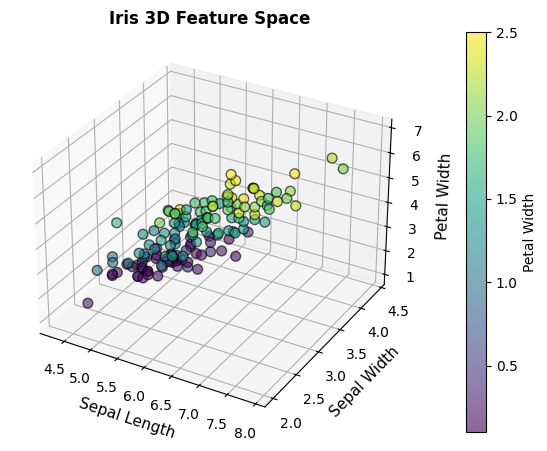

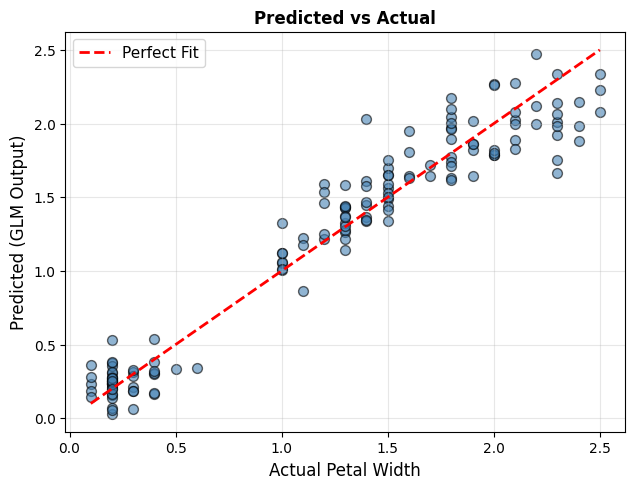

In [64]:
# Load Iris dataset (you can load from sklearn or pull the data arrays from Numerics)
iris = load_iris()
X_iris = iris.data  # Shape: (150, 4) - 150 samples, 4 features
y_iris = iris.target

sepal_length = X_iris[:, 0]
sepal_width  = X_iris[:, 1]
petal_length = X_iris[:, 2]
petal_width  = X_iris[:, 3]

# Convert to Numerics format (features as rows, samples as columns)
list_multi = List[Array[Double]]()
list_multi.Add(convert_to_dotnet_array(sepal_length))
list_multi.Add(convert_to_dotnet_array(sepal_width))
list_multi.Add(convert_to_dotnet_array(petal_length))

X_multi = Matrix(list_multi)
X_multi.Header = Array[String](["Sepal Length", "Sepal Width", "Petal Length"])

y_net_multi = convert_to_dotnet_array(petal_width)
y_multi = Vector(y_net_multi)
y_multi.Header = 'Petal Width'

glm_multi = GeneralizedLinearModel(X_multi, y_multi)
glm_multi.Train()

summary_lines_multi = glm_multi.Summary()

print("\nModel Summary:")
print("\n".join(summary_lines_multi))

# Add intercept column to X_iris
n_samples = len(sepal_length)
X_with_intercept_multi = np.column_stack([
    np.ones(n_samples),  # Intercept column
    sepal_length,
    sepal_width,
    petal_length
])
X_net_array_multi = convert_to_dotnet_2d_array(X_with_intercept_multi)
X_pred_multi = Matrix(X_net_array_multi)

y_pred_multi = glm_multi.Predict(X_pred_multi)

# Figure 1: 3D scatter
fig1 = plt.figure(figsize=(14, 5))
ax1 = fig1.add_axes([0.1, 0.1, 0.8, 0.8], projection='3d')

scatter = ax1.scatter(
    sepal_length, sepal_width, petal_length,
    c=petal_width, cmap='viridis', alpha=0.6, s=50, edgecolor='black'
)
ax1.set_xlabel('Sepal Length', fontsize=11)
ax1.set_ylabel('Sepal Width', fontsize=11)
ax1.set_zlabel('Petal Width', fontsize=11)
ax1.set_title('Iris 3D Feature Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Petal Width')

plt.show()

# Predicted vs Actual
fig2 = plt.figure(figsize=(7, 5))
ax2 = fig2.add_axes([0.1, 0.1, 0.8, 0.8])

ax2.scatter(petal_width, y_pred_multi, alpha=0.6, s=50,
            color='steelblue', edgecolor='black')
ax2.plot(
    [petal_width.min(), petal_width.max()],
    [petal_width.min(), petal_width.max()],
    'r--', linewidth=2, label='Perfect Fit'
)
ax2.set_xlabel('Actual Petal Width', fontsize=12)
ax2.set_ylabel('Predicted (GLM Output)', fontsize=12)
ax2.set_title('Predicted vs Actual', fontsize=12, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.show()



## 3. Logistic Regression (Logit Link)

For binary outcomes (0/1): **logit(p) = log(p/(1-p)) = β₀ + β₁x₁ + ...**

Models probability of "success" (y=1).

Admission rate: 70.5%
Admitted: 141.0 / 200

Model Summary:

Generalized Linear Model (200 obs, 3 parameters):
Model for predicting Y Data:
Parameters:
                   Estimate  Std. Error     z value    Pr(>|z|)
Intercept          -7.74875     2.62992      -2.946      0.0032 **
β1                  0.01455     0.00730       1.995      0.0461 *
β2                  1.32547     0.41632       3.184      0.0015 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4417 on 197 degrees of freedom
AIC: 232.8318  AICc: 232.9542  BIC: 242.7267

Residuals:
       Min        1Q    Median        3Q       Max
   -0.8732   -0.4998    0.1792    0.2969    0.6313


Classification Accuracy: 71.0%

Confusion Matrix:
[[  9  50]
 [  8 133]]


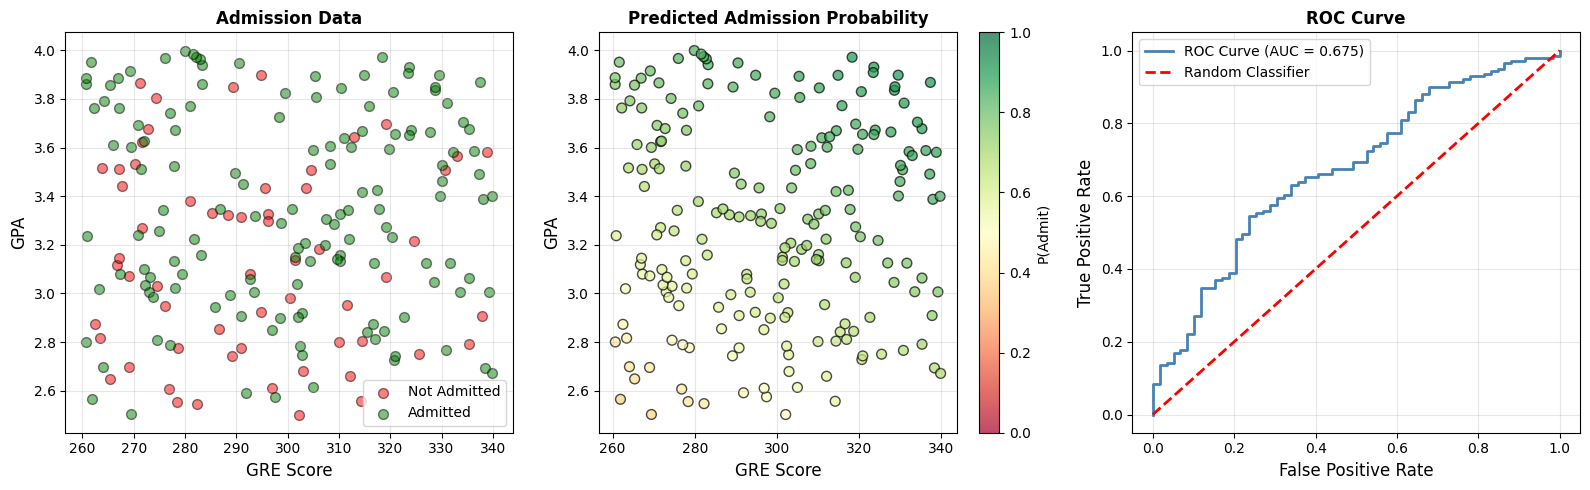

In [71]:
# Generate binary outcome data (admission based on test scores)
np.random.seed(456)
n = 200

gre_score = np.random.uniform(260, 340, n)
gpa = np.random.uniform(2.5, 4.0, n)

# Probability of admission
logit = -6 + 0.01 * gre_score + 1.2 * gpa
prob_admit = 1 / (1 + np.exp(-logit))
admitted = (np.random.uniform(0, 1, n) < prob_admit).astype(float)

print(f"Admission rate: {np.mean(admitted):.1%}")
print(f"Admitted: {np.sum(admitted)} / {n}")

# Fit logistic regression
X_logit_np = np.column_stack([gre_score, gpa])
X_logit_net = convert_to_dotnet_2d_array(X_logit_np)
y_logit_net = convert_to_dotnet_array(admitted)

X_logit = Matrix(X_logit_net)
y_logit = Vector(y_logit_net)

glm_logit = GeneralizedLinearModel(X_logit, y_logit, True, GeneralizedLinearModel.LinkFunctionType.Logit)
glm_logit.Train()

summary_lines_logit = glm_logit.Summary()

print("\nModel Summary:")
print("\n".join(summary_lines_logit))

n_samples = len(gre_score)
X_with_intercept_logit = np.column_stack([
    np.ones(n_samples),  # Intercept column
    X_logit_np
])
X_net_array_logit = convert_to_dotnet_2d_array(X_with_intercept_logit)
X_pred_logit = Matrix(X_net_array_logit)

y_pred_logit = glm_logit.Predict(X_pred_logit)

#  Classification (threshold = 0.5)
admitted_pred = np.zeros(n)
for i in range(n):
    if y_pred_logit[i] > 0.5:
        admitted_pred[i] = 1.0
    else:
        admitted_pred[i] = 0.0
accuracy = np.mean(admitted_pred == admitted)

print(f"\nClassification Accuracy: {accuracy:.1%}")

# Confusion matrix
cm = confusion_matrix(admitted, admitted_pred)
print("\nConfusion Matrix:")
print(cm)

#  Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# GRE vs Admission
axes[0].scatter(gre_score[admitted == 0], gpa[admitted == 0], 
               alpha=0.5, s=50, color='red', label='Not Admitted', edgecolor='black')
axes[0].scatter(gre_score[admitted == 1], gpa[admitted == 1], 
               alpha=0.5, s=50, color='green', label='Admitted', edgecolor='black')
axes[0].set_xlabel('GRE Score', fontsize=12)
axes[0].set_ylabel('GPA', fontsize=12)
axes[0].set_title('Admission Data', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Predicted probabilities
scatter = axes[1].scatter(gre_score, gpa, c=y_pred_logit, cmap='RdYlGn', 
                         alpha=0.7, s=50, edgecolor='black', vmin=0, vmax=1)
axes[1].set_xlabel('GRE Score', fontsize=12)
axes[1].set_ylabel('GPA', fontsize=12)
axes[1].set_title('Predicted Admission Probability', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='P(Admit)')
axes[1].grid(True, alpha=0.3)

# ROC-like plot
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(admitted, y_pred_logit)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, linewidth=2, color='steelblue', 
            label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[2].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
axes[2].set_xlabel('False Positive Rate', fontsize=12)
axes[2].set_ylabel('True Positive Rate', fontsize=12)
axes[2].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Poisson Regression (Log Link)

For count data: **log(λ) = β₀ + β₁x₁ + ...**

Models rates or counts.

Death count statistics:
  Mean: 29.98
  Min: 0, Max: 124

Model Summary:

Generalized Linear Model (50 obs, 3 parameters):
Model for predicting Y Data:
Parameters:
                   Estimate  Std. Error     z value    Pr(>|z|)
β1                 -1.12604     0.03722     -30.257     < 1E-15 ***
β2                  0.00103     0.00001     131.283     < 1E-15 ***
β3                  0.00313     0.00003     104.216     < 1E-15 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.6200 on 47 degrees of freedom
AIC: 275.2048  AICc: 275.7266  BIC: 280.9409

Residuals:
       Min        1Q    Median        3Q       Max
  -12.5901   -1.6387   -0.0648    2.4570   10.3646



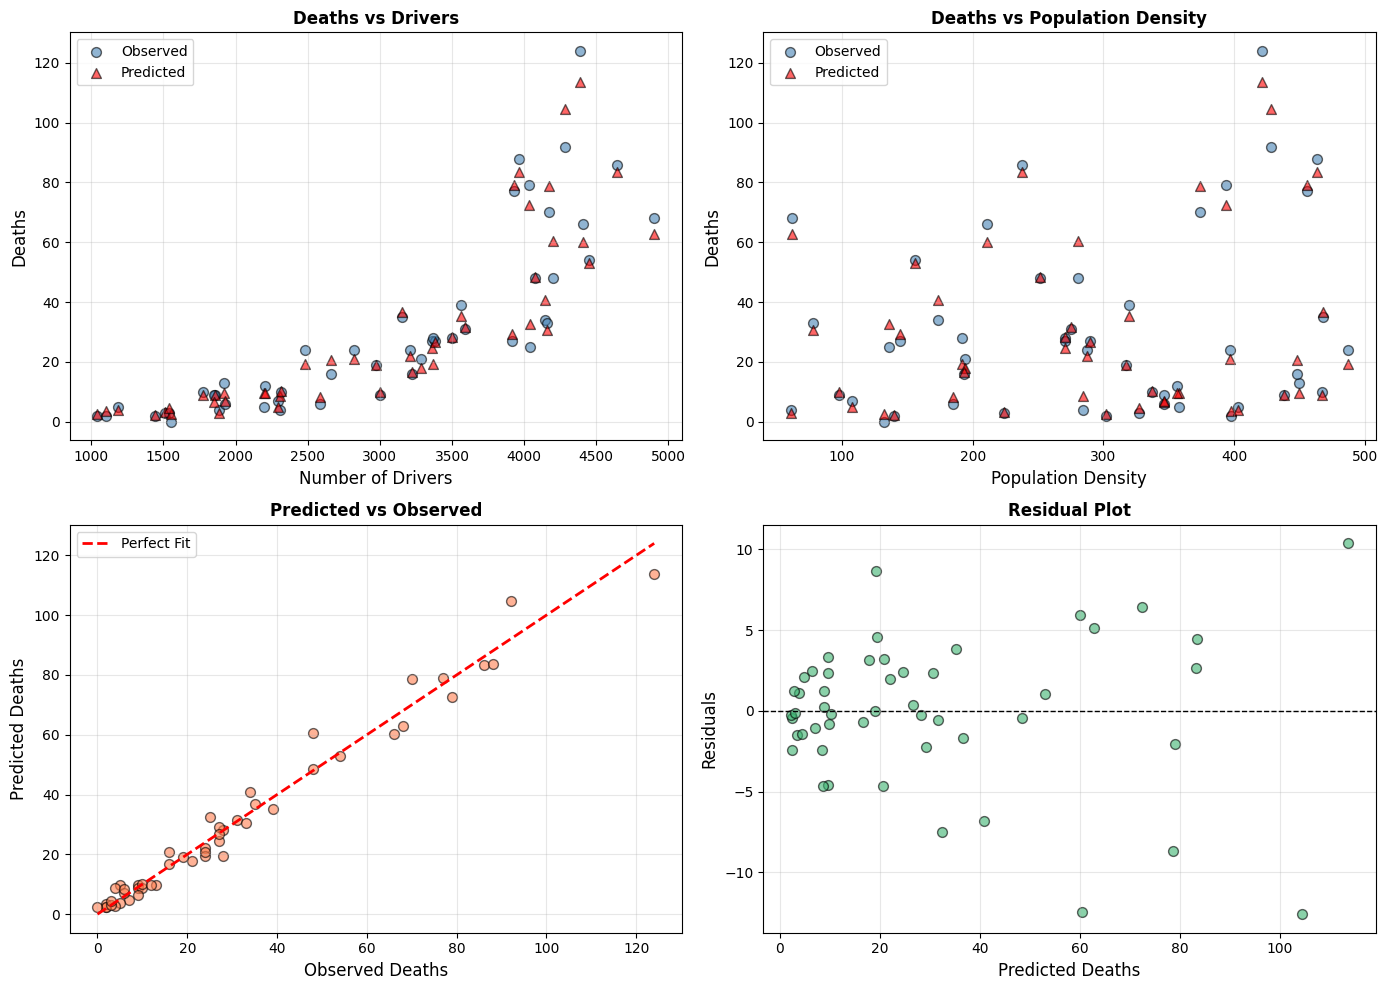

In [72]:
# Generate count data (deaths per region based on drivers and population density)
np.random.seed(789)
n = 50

drivers = np.random.uniform(1000, 5000, n)
popden = np.random.uniform(50, 500, n)

# Expected count (rate)
log_lambda = -1 + 0.001 * drivers + 0.003 * popden
lambda_true = np.exp(log_lambda)
deaths = np.random.poisson(lambda_true)

print(f"Death count statistics:")
print(f"  Mean: {np.mean(deaths):.2f}")
print(f"  Min: {np.min(deaths)}, Max: {np.max(deaths)}")

# Fit Poisson regression
X_poisson_np = np.column_stack([np.ones(n), # Forcing an intercept column
                             drivers, popden])
X_poisson_net = convert_to_dotnet_2d_array(X_poisson_np)
y_poisson_net = convert_to_dotnet_array(deaths.astype(float))

X_poisson = Matrix(X_poisson_net)
y_poisson = Vector(y_poisson_net)

# Note the intercept is included in X_poisson so we set hasIntercept=False!
glm_poisson = GeneralizedLinearModel(X_poisson, y_poisson, False, GeneralizedLinearModel.LinkFunctionType.Log)
glm_poisson.Train()

summary_lines_poisson = glm_poisson.Summary()
print("\nModel Summary:")
print("\n".join(summary_lines_poisson))

X_pred_poisson = Matrix(X_poisson_net)

y_pred_poisson = glm_poisson.Predict(X_pred_poisson)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Drivers vs Deaths
axes[0, 0].scatter(drivers, deaths, alpha=0.6, s=50, color='steelblue', 
                  edgecolor='black', label='Observed')
axes[0, 0].scatter(drivers, y_pred_poisson, alpha=0.6, s=50, color='red', 
                  marker='^', edgecolor='black', label='Predicted')
axes[0, 0].set_xlabel('Number of Drivers', fontsize=12)
axes[0, 0].set_ylabel('Deaths', fontsize=12)
axes[0, 0].set_title('Deaths vs Drivers', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Pop Density vs Deaths
axes[0, 1].scatter(popden, deaths, alpha=0.6, s=50, color='steelblue', 
                  edgecolor='black', label='Observed')
axes[0, 1].scatter(popden, y_pred_poisson, alpha=0.6, s=50, color='red', 
                  marker='^', edgecolor='black', label='Predicted')
axes[0, 1].set_xlabel('Population Density', fontsize=12)
axes[0, 1].set_ylabel('Deaths', fontsize=12)
axes[0, 1].set_title('Deaths vs Population Density', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Predicted vs Actual
axes[1, 0].scatter(deaths, y_pred_poisson, alpha=0.6, s=50, color='coral', edgecolor='black')
axes[1, 0].plot([deaths.min(), deaths.max()], [deaths.min(), deaths.max()], 
               'r--', linewidth=2, label='Perfect Fit')
axes[1, 0].set_xlabel('Observed Deaths', fontsize=12)
axes[1, 0].set_ylabel('Predicted Deaths', fontsize=12)
axes[1, 0].set_title('Predicted vs Observed', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Residuals
residuals_poisson = deaths - y_pred_poisson
axes[1, 1].scatter(y_pred_poisson, residuals_poisson, alpha=0.6, s=50, 
                  color='mediumseagreen', edgecolor='black')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Predicted Deaths', fontsize=12)
axes[1, 1].set_ylabel('Residuals', fontsize=12)
axes[1, 1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Alternative Link Functions

Different link functions for binary data:
- **Probit**: Φ⁻¹(p) - assumes normal latent variable
- **Complementary log-log**: log(-log(1-p)) - asymmetric, good for rare events

Admission rate: 70.5%
Admitted: 141.0 / 200

Link Function Comparison:
                 Link        AIC        BIC  Intercept   β(GRE)   β(GPA)
               Probit 232.719245 242.614197  -4.638157 0.008684 0.798685
Complementary Log-Log 232.516584 242.411536  -4.835403 0.008374 0.776554

(Lower AIC/BIC = better fit)


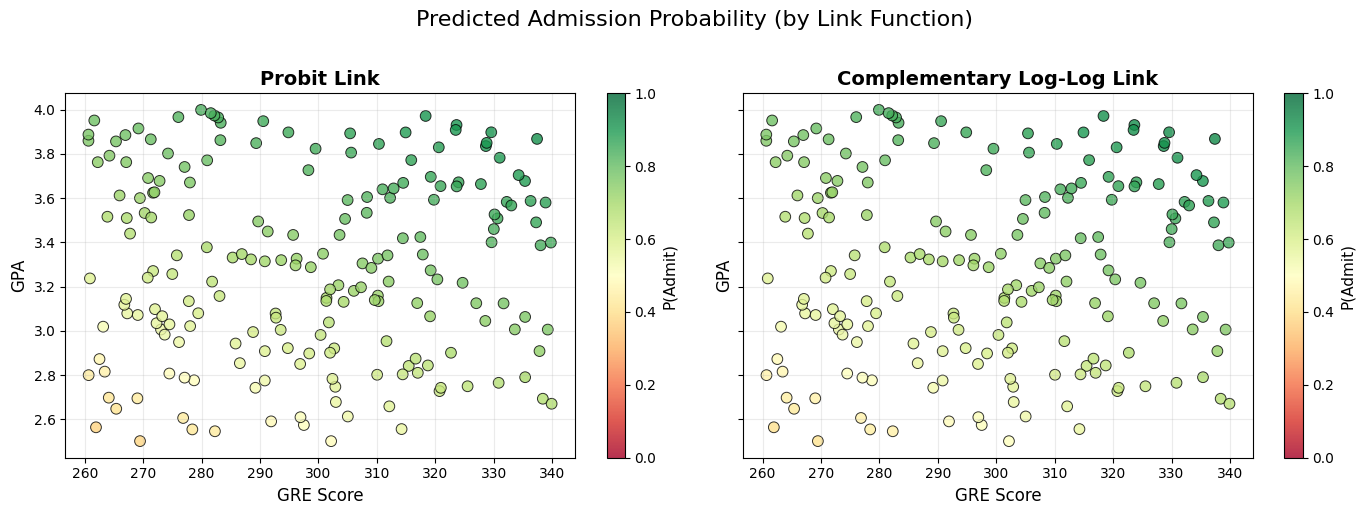

In [76]:
# Use same admission data
# Generate binary outcome data (admission based on test scores)
np.random.seed(456)
n = 200

gre_score = np.random.uniform(260, 340, n)
gpa = np.random.uniform(2.5, 4.0, n)

# Probability of admission
logit = -6 + 0.01 * gre_score + 1.2 * gpa
prob_admit = 1 / (1 + np.exp(-logit))
admitted = (np.random.uniform(0, 1, n) < prob_admit).astype(float)

print(f"Admission rate: {np.mean(admitted):.1%}")
print(f"Admitted: {np.sum(admitted)} / {n}")

# Fit logistic regression
X_alt_np = np.column_stack([np.ones(n),gre_score, gpa])
X_alt_net = convert_to_dotnet_2d_array(X_alt_np)
y_alt_net = convert_to_dotnet_array(admitted)

X_alt = Matrix(X_alt_net)
y_alt = Vector(y_alt_net)

X_pred_alt = Matrix(X_alt_net)


link_functions = {
    'Probit': GeneralizedLinearModel.LinkFunctionType.Probit,
    'Complementary Log-Log': GeneralizedLinearModel.LinkFunctionType.ComplementaryLogLog
}

results_links = {}

for name, link in link_functions.items():
    glm_link = GeneralizedLinearModel(X_alt, y_alt, False, link)
    glm_link.Train()
    prob_link = convert_to_dotnet_array(glm_link.Predict(X_pred_alt))
    
    results_links[name] = {
        'model': glm_link,
        'probabilities': prob_link,
        'coefficients': glm_link.Parameters,
        'aic': glm_link.AIC,
        'bic': glm_link.BIC
    }

links = list(results_links.keys())

# Compare models
comparison_df = pd.DataFrame({
    'Link': links,
    'AIC': [results_links[k]['aic'] for k in results_links],
    'BIC': [results_links[k]['bic'] for k in results_links],
    'Intercept': [results_links[k]['coefficients'][0] for k in results_links],
    'β(GRE)': [results_links[k]['coefficients'][1] for k in results_links],
    'β(GPA)': [results_links[k]['coefficients'][2] for k in results_links]
})


print("\nLink Function Comparison:")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("\n(Lower AIC/BIC = better fit)")

# Visualize predicted probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

plot_order = ["Probit", "Complementary Log-Log"]

for ax, name in zip(axes, plot_order):
    model = results_links[name]["model"]

    # Predicted probability at each observed data point
    p_hat = np.array(list(model.Predict(X_pred_alt)), dtype=float)

    sc = ax.scatter(
        gre_score,
        gpa,
        c=p_hat,
        cmap="RdYlGn",
        vmin=0.0,
        vmax=1.0,
        s=60,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.7
    )

    ax.set_title(f"{name} Link", fontsize=14, fontweight="bold")
    ax.set_xlabel("GRE Score", fontsize=12)
    ax.set_ylabel("GPA", fontsize=12)
    ax.grid(True, alpha=0.25)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("P(Admit)", fontsize=11)

plt.suptitle("Predicted Admission Probability (by Link Function)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



## 6. Model Diagnostics and Interpretation

Understanding GLM outputs.

In [ ]:
# Use logistic regression model for detailed diagnostics
coef = glm_logit.Parameters
se = glm_logit.ParameterStandardErrors


print("\nDetailed Logistic Regression Results:")
print("=" * 70)
print(f"\nCoefficients (log-odds scale):")
print(f"  Intercept: {coef[0]:.4f} (SE: {se[0]:.4f})")
print(f"  GRE:        {coef[1]:.4f} (SE: {se[1]:.4f})")
print(f"  GPA:        {coef[2]:.4f} (SE: {se[2]:.4f})")


# Odds ratios (exponentiated coefficients)
odds_ratios = np.exp(coef)
print(f"\nOdds Ratios:")
print(f"  GRE: {odds_ratios[1]:.4f}")
print(f"  → 1-point increase in GRE multiplies odds of admission by {odds_ratios[1]:.4f}")
print(f"  GPA: {odds_ratios[2]:.4f}")
print(f"  → 1-point increase in GPA multiplies odds of admission by {odds_ratios[2]:.4f}")

# Predicted probabilities for specific values
example_students = np.array([
    [300, 3.0],  # Average GRE, Average GPA
    [340, 4.0],  # High GRE, High GPA
    [260, 2.5]   # Low GRE, Low GPA
])

example_students_net = convert_to_dotnet_2d_array(np.column_stack([
    np.ones(example_students.shape[0]),  # Intercept column
    example_students
]))

example = Matrix(example_students_net)
predicted_probs = glm_logit.Predict(example)


print(f"\nExample Predictions:")
print(f"  GRE=300, GPA=3.0: P(Admit) = {predicted_probs[0]:.1%}")
print(f"  GRE=340, GPA=4.0: P(Admit) = {predicted_probs[1]:.1%}")
print(f"  GRE=260, GPA=2.5: P(Admit) = {predicted_probs[2]:.1%}")


Detailed Logistic Regression Results:

Coefficients (log-odds scale):
  Intercept: -7.7487 (SE: 2.6299)
  GRE:        0.0146 (SE: 0.0073)
  GPA:        1.3255 (SE: 0.4163)

Odds Ratios:
  GRE: 1.0147
  → 1-point increase in GRE multiplies odds of admission by 1.0147
  GPA: 3.7639
  → 1-point increase in GPA multiplies odds of admission by 3.7639

Example Predictions:
  GRE=300, GPA=3.0: P(Admit) = 64.4%
  GRE=340, GPA=4.0: P(Admit) = 92.4%
  GRE=260, GPA=2.5: P(Admit) = 34.3%


## Summary

You've learned:
- Linear regression with identity link
- Multiple regression
- Logistic regression for binary outcomes
- Poisson regression for count data
- Alternative link functions (probit, cloglog)
- Model interpretation and diagnostics

## Key Takeaways

1. **GLMs extend linear models** - Handle non-normal responses via link functions
2. **Choose link based on data type** - Identity for continuous, logit for binary, log for counts
3. **Coefficients have specific interpretations** - Log-odds for logit, log-rate for Poisson
4. **AIC/BIC for model comparison** - Lower is better
5. **Always check residuals** - Assess model fit

## GLM Selection Guide

| Data Type | Link Function | Use Case |
|-----------|---------------|----------|
| Continuous | Identity | Standard regression |
| Binary (0/1) | Logit | Classification, probability |
| Binary (rare events) | Comp Log-Log | Rare disease, failure |
| Binary (normal latent) | Probit | Dose-response |
| Count | Log | Event counts, rates |
| Positive continuous | Log | Skewed data, multiplicative |

## Next Steps

- **09_machine_learning.ipynb** - Advanced predictive models
- **07_statistics.ipynb** - Hypothesis testing

## Exercise

1. Generate binary outcome data
2. Fit logistic regression
3. Compute predicted probabilities
4. Calculate classification accuracy
5. Compare with probit link - which fits better?